In [27]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import re
import pandas as pd

In [28]:
work_dir = Path("WORKDIR")
tka_files = list(work_dir.glob("*.TKA"))
first_spectrum = np.loadtxt(tka_files[0])
summed_spectrum = np.zeros_like(first_spectrum)
for file_path in tka_files:
    summed_spectrum += np.loadtxt(file_path)
channels = np.arange(len(summed_spectrum))

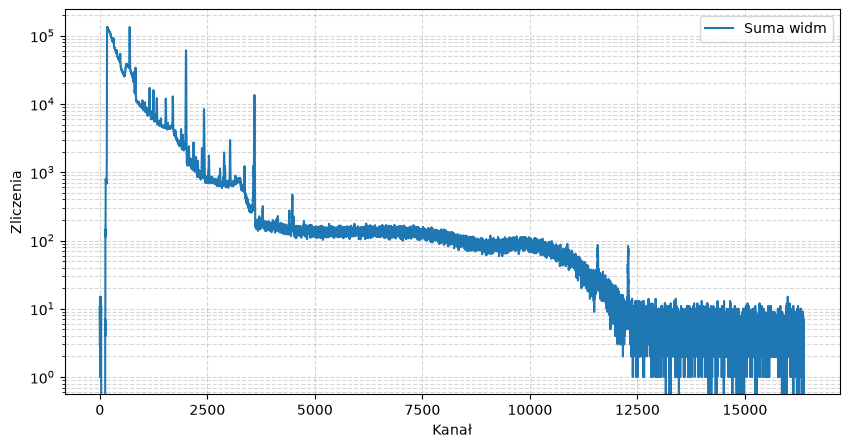

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(channels, summed_spectrum, drawstyle='steps-mid', label='Suma widm')
plt.yscale('log')
plt.xlabel('Kanał')
plt.ylabel('Zliczenia')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Znalezione kanały: [  172   396   694   829   992  1157  1324  1434  1534  1697  1890  2004
  2179  2280  2423  2537  2766  2890  3029  3152  3365  3595  3789  4477
 10709 10871 10971 11143 11578 12284]


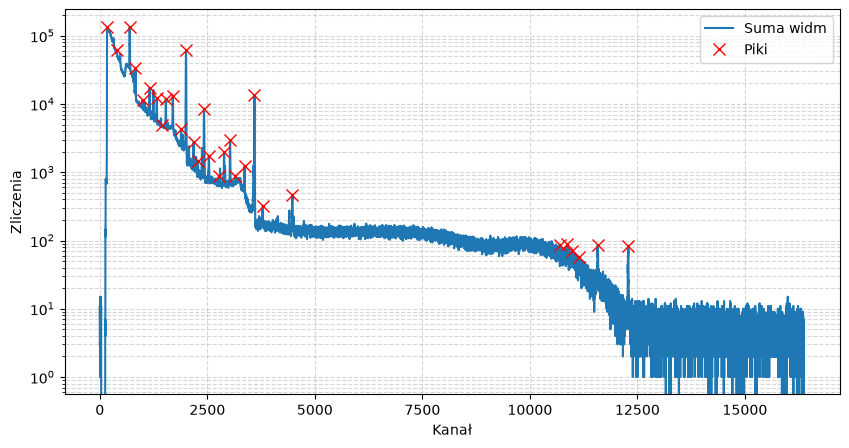

In [30]:
prominences = np.where(channels > 10700, 25, 150)
heights = np.where(channels > 10700, 50, 150)

peaks, properties = find_peaks(
    summed_spectrum,
    height=heights,
    distance=100,
    prominence=prominences
)

print("Znalezione kanały:", peaks)

plt.figure(figsize=(10, 5))
plt.plot(channels, summed_spectrum, drawstyle='steps-mid', label='Suma widm')
# 'rx' rysuje czerwone iksy w miejscach pików
plt.plot(peaks, summed_spectrum[peaks], 'rx', markersize=8, label='Piki')
plt.yscale('log')
plt.xlabel('Kanał')
plt.ylabel('Zliczenia')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [31]:
# Aktualna baza danych energii gamma w keV (z uwzględnieniem naturalnego tła Bi-214 i Tl-208)

# 1. Database of gamma energies in keV
GAMMA_DB = {
    # --- 11B lines from 10B(n,g)11B reaction (ENSDF/NNDC) + SE/DE escape peaks ---
    # Intensities (I_g) given per 100 thermal neutron captures in 10B(n,g)
    r"$^{11}\mathrm{B}\ 8917\ $": 8916.67,  # I_g = 85.0(20)%
    r"$^{11}\mathrm{B}\ 8917\ \mathrm{Escape Peak}$": (
        8405.67
    ),  # 8916.67 - 511.00 (Escape intensity depends on detector geometry)
    # --- Background lines ---
    # Absolute gamma intensity per decay of parent nuclide
    r"$^{40}\mathrm{K}$": 1460.822,  # I_g = 10.66(11)% per 40K decay
    r"$^{208}\mathrm{Tl}\ 583$": (
        583.191  # I_g = 85.0(3)% per 208Tl decay (30.55% per 228Th decay equilibrium)
    ),
    r"$^{208}\mathrm{Tl}\ 2615$": (
        2614.511  # I_g = 99.754(4)% per 208Tl decay (35.8% per 228Th decay equilibrium)
    ),
    r"$^{214}\mathrm{Bi}\ 609$": 609.312,  # I_g = 45.49(16)% per 214Bi decay
    r"$^{214}\mathrm{Bi}\ 1120$": 1120.294,  # I_g = 14.92(3)% per 214Bi decay
    # r"$^{214}\mathrm{Bi}\ 1764$": 1764.494, # I_g = 15.31(5)% per 214Bi decay
    # r"$^{214}\mathrm{Bi}\ 2204$": 2204.21,  # I_g = 4.98(2)% per 214Bi decay
    # --- 56Co calibration source lines ---
    # Absolute gamma intensity per 100 decays of 56Co (NNDC / ENSDF)
    r"$^{56}\mathrm{Co}\ 847$": 846.771,  # I_g = 99.9399(23)%
    r"$^{56}\mathrm{Co}\ 1038$": 1037.840,  # I_g = 14.05(4)%
    r"$^{56}\mathrm{Co}\ 1238$": 1238.282,  # I_g = 66.41(20)%
    # r"$^{56}\mathrm{Co}\ 1771$": 1771.351,  # I_g = 15.41(6)%
    r"$^{56}\mathrm{Co}\ 2598$": 2598.458,  # I_g = 16.97(6)%
    r"$^{56}\mathrm{Co}\ 3202$": 3202.028,  # I_g = 3.207(14)%
    r"$^{56}\mathrm{Co}\ 3253$": 3253.416,  # I_g = 7.88(3)%
    r"$^{56}\mathrm{Co}\ 3273$": 3272.99,  # I_g = 1.86(2)%
    r"$^{56}\mathrm{Co}\ 3451$": 3451.15,  # I_g = 0.947(7)%
}

In [32]:
#coarse linear fit for 11B and 40K
# 1. Wyznaczenie kanału 11B jako ostatniego piku na prawo
ch_B11 = peaks[-1]

# 2. Wyznaczenie 40K (np. najsilniejszy pik z 'peaks' w obszarze 1000-2500)
mask_K40 = (peaks > 1000) & (peaks < 2500)
candidates_K40 = peaks[mask_K40]
ch_K40 = candidates_K40[np.argmax(summed_spectrum[candidates_K40])]

# 3. Wyliczenie współczynników prostej E(ch) = a * ch + b
E_K40 = GAMMA_DB[ r"$^{40}\mathrm{K}$"]          # 1460.83 keV
E_B11 = GAMMA_DB[r"$^{11}\mathrm{B}\ 8917\ $"]  # 8916.67 keV

a_0 = (E_B11 - E_K40) / (ch_B11 - ch_K40)
b_0 = E_K40 - a_0 * ch_K40

print(f"Kanał 40K: {ch_K40} | Kanał 11B: {ch_B11}")
print(f"Wstępne równanie: E(ch) = {a_0:.5f} * ch + ({b_0:.2f}) [keV]")

Kanał 40K: 2004 | Kanał 11B: 12284
Wstępne równanie: E(ch) = 0.72528 * ch + (7.37) [keV]


           LINEAR vs QUADRATIC FIT COMPARISON           
LINEAR FIT:    E(ch) = (0.72509356 ± 0.00000522)*ch + (7.91402 ± 0.01062)
               Chi2 = 72.6012 | ndof = 8 | Chi2_red = 9.0751 | Accepted = 10/10
---------------------------------------------------------
QUADRATIC FIT: E(ch) = (1.384324e-08 ± 1.785357e-09)*ch^2 + (0.72502031 ± 0.00001079)*ch + (7.98410 ± 0.01395)
               Chi2 = 12.4818 | ndof = 7 | Chi2_red = 1.7831 | Accepted = 10/10



<>:182: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:183: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:190: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:191: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:192: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:182: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:183: SyntaxWarning: "\ " is an invalid escape sequence. Such sequen

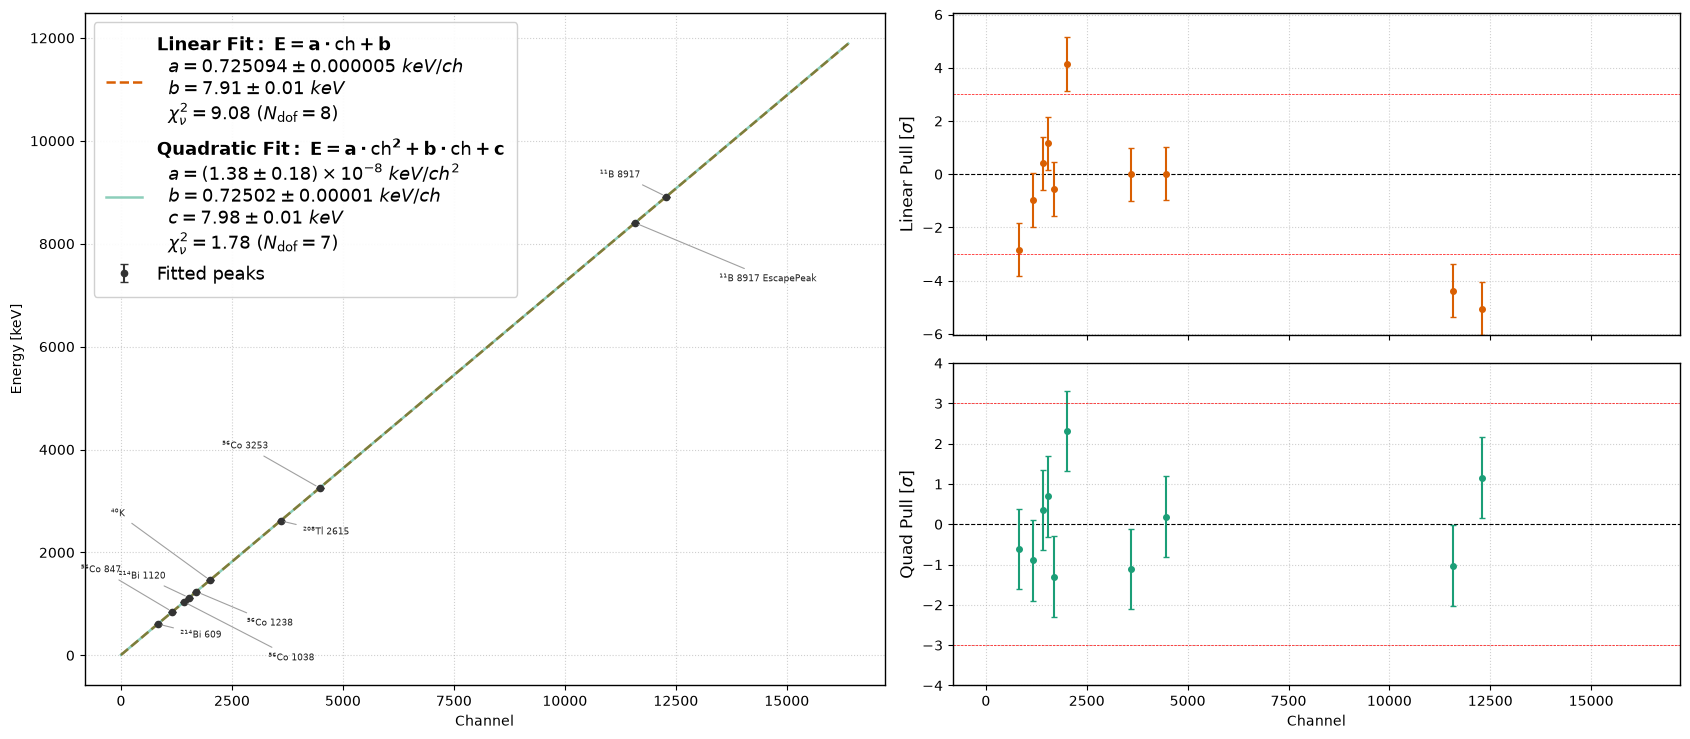

In [33]:

# --- 2. Model & Helper Functions ---
def gaus_lin_bg(x, amp, mean, sigma, bg_a, bg_b):
    return amp * np.exp(-((x - mean) ** 2) / (2 * sigma**2)) + bg_a * x + bg_b


def lin_func(x, a, b):
    """Linear calibration function: E(ch) = a * ch + b"""
    return a * x + b


def quad_func(x, a, b, c):
    """Quadratic calibration function: E(ch) = a * ch^2 + b * ch + c"""
    return a * x**2 + b * x + c


def fmt_tex(val, err):
    """Formats numbers nicely into LaTeX scientific/decimal notation."""
    if abs(val) < 1e-3 or abs(val) >= 1e4:
        exp = int(np.floor(np.log10(abs(val))))
        m_val = val / (10**exp)
        m_err = err / (10**exp)
        return f"({m_val:.2f} \\pm {m_err:.2f}) \\times 10^{{{exp}}}"
    else:
        prec = max(0, -int(np.floor(np.log10(abs(err))))) if err > 0 else 2
        return f"{val:.{prec}f} \\pm {err:.{prec}f}"


# --- 3. Peak Fitting with Position Uncertainty Extraction (sigma_ch) ---
matched_channels = []
matched_sigmas_ch = []
matched_energies = []
matched_labels = []

tolerance_keV = 30.0
window = 20

for ch_peak in peaks:
    e_est = a_0 * ch_peak + b_0

    best_label = min(GAMMA_DB, key=lambda k: abs(GAMMA_DB[k] - e_est))
    best_e = GAMMA_DB[best_label]

    if abs(best_e - e_est) <= tolerance_keV:
        roi_mask = (channels >= ch_peak - window) & (
            channels <= ch_peak + window
        )
        x_roi = channels[roi_mask]
        y_roi = summed_spectrum[roi_mask]

        p0 = [y_roi.max() - y_roi.min(), ch_peak, 5.0, 0.0, y_roi.min()]
        bounds = (
            [0, ch_peak - window, 0.5, -np.inf, 0],
            [np.inf, ch_peak + window, window, np.inf, np.inf],
        )

        try:
            popt, pcov = curve_fit(
                gaus_lin_bg, x_roi, y_roi, p0=p0, bounds=bounds
            )
            exact_ch = popt[1]
            sigma_ch = np.sqrt(pcov[1, 1])

            matched_channels.append(exact_ch)
            matched_sigmas_ch.append(sigma_ch)
            matched_energies.append(best_e)
            matched_labels.append(best_label)
        except (RuntimeError, ValueError):
            continue

matched_channels = np.array(matched_channels)
matched_sigmas_ch = np.array(matched_sigmas_ch)
matched_energies = np.array(matched_energies)
matched_labels = np.array(matched_labels)

sigma_E = a_0 * matched_sigmas_ch
max_dev_keV = 10.0

# --- 4A. LINEAR FIT (Iterative Outlier Elimination) ---
keep_lin = np.ones(len(matched_channels), dtype=bool)
for _ in range(5):
    popt_lin, pcov_lin = curve_fit(
        lin_func,
        matched_channels[keep_lin],
        matched_energies[keep_lin],
        p0=[a_0, b_0],
        sigma=sigma_E[keep_lin],
        absolute_sigma=True,
    )
    E_lin_temp = lin_func(matched_channels, *popt_lin)
    new_mask = keep_lin & (np.abs(E_lin_temp - matched_energies) <= max_dev_keV)
    if np.array_equal(new_mask, keep_lin):
        break
    keep_lin = new_mask

a_lin, b_lin = popt_lin
err_a_lin, err_b_lin = np.sqrt(np.diag(pcov_lin))
E_lin = lin_func(matched_channels, a_lin, b_lin)
res_lin = E_lin - matched_energies
pulls_lin = res_lin / sigma_E

chi2_lin = np.sum((pulls_lin[keep_lin]) ** 2)
ndof_lin = np.sum(keep_lin) - 2
chi2_red_lin = chi2_lin / ndof_lin if ndof_lin > 0 else np.nan

# --- 4B. QUADRATIC FIT (Iterative Outlier Elimination) ---
keep_quad = np.ones(len(matched_channels), dtype=bool)
for _ in range(5):
    popt_quad, pcov_quad = curve_fit(
        quad_func,
        matched_channels[keep_quad],
        matched_energies[keep_quad],
        p0=[0.0, a_0, b_0],
        sigma=sigma_E[keep_quad],
        absolute_sigma=True,
    )
    E_quad_temp = quad_func(matched_channels, *popt_quad)
    new_mask = keep_quad & (
        np.abs(E_quad_temp - matched_energies) <= max_dev_keV
    )
    if np.array_equal(new_mask, keep_quad):
        break
    keep_quad = new_mask

a_quad, b_quad, c_quad = popt_quad
err_a_quad, err_b_quad, err_c_quad = np.sqrt(np.diag(pcov_quad))
E_quad = quad_func(matched_channels, a_quad, b_quad, c_quad)
res_quad = E_quad - matched_energies
pulls_quad = res_quad / sigma_E

chi2_quad = np.sum((pulls_quad[keep_quad]) ** 2)
ndof_quad = np.sum(keep_quad) - 3
chi2_red_quad = chi2_quad / ndof_quad if ndof_quad > 0 else np.nan

# --- 5. PRINT COMPARISON SUMMARY ---
print("=========================================================")
print("           LINEAR vs QUADRATIC FIT COMPARISON           ")
print("=========================================================")
print(
    f"LINEAR FIT:    E(ch) = ({a_lin:.8f} ± {err_a_lin:.8f})*ch + ({b_lin:.5f} ± {err_b_lin:.5f})"
)
print(
    f"               Chi2 = {chi2_lin:.4f} | ndof = {ndof_lin} | Chi2_red = {chi2_red_lin:.4f} | Accepted = {np.sum(keep_lin)}/{len(matched_channels)}"
)
print("---------------------------------------------------------")
print(
    f"QUADRATIC FIT: E(ch) = ({a_quad:.6e} ± {err_a_quad:.6e})*ch^2 + ({b_quad:.8f} ± {err_b_quad:.8f})*ch + ({c_quad:.5f} ± {err_c_quad:.5f})"
)
print(
    f"               Chi2 = {chi2_quad:.4f} | ndof = {ndof_quad} | Chi2_red = {chi2_red_quad:.4f} | Accepted = {np.sum(keep_quad)}/{len(matched_channels)}"
)
print("=========================================================\n")

# --- 6. PLOTTING COMPARISON (Expanded Right-Side Pull Layout) ---
plt.style.use("default")

# Adjusted figure size and width ratios (1.1 : 1) to make right pull plots much longer horizontally
fig, axd = plt.subplot_mosaic(
    [["main", "lin_pull"], ["main", "quad_pull"]],
    figsize=(17, 7.5),
    width_ratios=[1.1, 1],
    sharex=True,
)

ax1 = axd["main"]
ax2 = axd["lin_pull"]
ax3 = axd["quad_pull"]

fig.patch.set_facecolor("white")
for ax in (ax1, ax2, ax3):
    ax.set_facecolor("white")
    ax.tick_params(colors="black", which="both")
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

ch_axis = np.linspace(0, channels.max(), 500)

# Legend Labels
lbl_lin = (
    r"$\bf{Linear\ Fit:}\ E = a\cdot\text{ch} + b$"
    "\n"
    f"  $a = {fmt_tex(a_lin, err_a_lin)}\ \t{{keV/ch}}$\n"
    f"  $b = {fmt_tex(b_lin, err_b_lin)}\ \t{{keV}}$\n"
    rf"  $\chi^2_\nu = {chi2_red_lin:.2f}$ ($N_\text{{dof}} = {ndof_lin}$)"
)

lbl_quad = (
    r"$\bf{Quadratic\ Fit:}\ E = a\cdot\text{ch}^2 + b\cdot\text{ch} + c$"
    "\n"
    f"  $a = {fmt_tex(a_quad, err_a_quad)}\ \t{{keV/ch}}^2$\n"
    f"  $b = {fmt_tex(b_quad, err_b_quad)}\ \t{{keV/ch}}$\n"
    f"  $c = {fmt_tex(c_quad, err_c_quad)}\ \t{{keV}}$\n"
    rf"  $\chi^2_\nu = {chi2_red_quad:.2f}$ ($N_\text{{dof}} = {ndof_quad}$)"
)

# --- Left Panel: Main Calibration Plot ---
accepted_both = keep_lin | keep_quad
ax1.errorbar(
    matched_channels[accepted_both],
    matched_energies[accepted_both],
    yerr=sigma_E[accepted_both],
    fmt="o",
    color="#333333",
    ecolor="#333333",
    markersize=4.5,
    capsize=3,
    label="Fitted peaks",
)

if np.sum(~accepted_both) > 0:
    ax1.errorbar(
        matched_channels[~accepted_both],
        matched_energies[~accepted_both],
        yerr=sigma_E[~accepted_both],
        fmt="x",
        color="#888888",
        ecolor="#888888",
        markersize=6,
        capsize=3,
        label="Rejected outliers",
    )

ax1.plot(
    ch_axis,
    lin_func(ch_axis, a_lin, b_lin),
    "--",
    color="#d95f02",
    linewidth=1.8,
    label=lbl_lin,
)

ax1.plot(
    ch_axis,
    quad_func(ch_axis, a_quad, b_quad, c_quad),
    "-",
    color="#1b9e77",
    linewidth=1.8,
    label=lbl_quad,
    alpha=0.5,
)

# Peak Annotations
angles_deg = [-36, 144]
base_lengths = [20, 45, 75]
for idx, (ch, e, label, is_ok) in enumerate(
    zip(matched_channels, matched_energies, matched_labels, accepted_both)
):
    color = "#222222" if is_ok else "#888888"
    angle_rad = np.radians(angles_deg[idx % len(angles_deg)])
    r = base_lengths[idx % len(base_lengths)]
    dx = r * np.cos(angle_rad)
    dy = r * np.sin(angle_rad)
    ha_align = "left" if dx >= 0 else "right"

    ax1.annotate(
        label,
        (ch, e),
        textcoords="offset points",
        xytext=(dx, dy),
        ha=ha_align,
        va="bottom",
        fontsize=6.5,
        color=color,
        arrowprops=dict(
            arrowstyle="-", color="#a0a0a0", lw=0.8, shrinkA=3, shrinkB=3
        ),
    )

ax1.set_xlabel("Channel", color="black")
ax1.set_ylabel("Energy [keV]", color="black")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(
    loc="upper left",
    frameon=True,
    fancybox=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=13,
    borderpad=0.7,
    labelspacing=0.5,
)

# --- Top-Right Panel: Extended Linear Pulls ---
ax2.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax2.errorbar(
    matched_channels[keep_lin],
    pulls_lin[keep_lin],
    yerr=np.ones_like(pulls_lin[keep_lin]),
    fmt="o",
    color="#d95f02",
    ecolor="#d95f02",
    markersize=4,
    capsize=2.5,
)
ax2.axhline(-3, color="red", linestyle="--", linewidth=0.5)
ax2.axhline(3, color="red", linestyle="--", linewidth=0.5)
if np.sum(~keep_lin) > 0:
    ax2.errorbar(
        matched_channels[~keep_lin],
        pulls_lin[~keep_lin],
        yerr=np.ones_like(pulls_lin[~keep_lin]),
        fmt="x",
        color="#7570b3",
        ecolor="#7570b3",
        markersize=5,
        capsize=2.5,
    )
ax2.set_ylabel("Linear Pull [$\\sigma$]", color="black", fontsize=12)
max_pull_lin = max(4, np.max(np.abs(pulls_lin)) + 1)
ax2.set_ylim(-max_pull_lin, max_pull_lin)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.tick_params(labelbottom=False)

# --- Bottom-Right Panel: Extended Quadratic Pulls ---
ax3.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax3.errorbar(
    matched_channels[keep_quad],
    pulls_quad[keep_quad],
    yerr=np.ones_like(pulls_quad[keep_quad]),
    fmt="o",
    color="#1b9e77",
    ecolor="#1b9e77",
    markersize=4,
    capsize=2.5,
)
ax3.axhline(-3, color="red", linestyle="--", linewidth=0.5)
ax3.axhline(3, color="red", linestyle="--", linewidth=0.5)
if np.sum(~keep_quad) > 0:
    ax3.errorbar(
        matched_channels[~keep_quad],
        pulls_quad[~keep_quad],
        yerr=np.ones_like(pulls_quad[~keep_quad]),
        fmt="x",
        color="#7570b3",
        ecolor="#7570b3",
        markersize=5,
        capsize=2.5,
    )
ax3.set_xlabel("Channel", color="black")
ax3.set_ylabel("Quad Pull [$\\sigma$]", color="black", fontsize=12)
max_pull_quad = max(4, np.max(np.abs(pulls_quad)) + 1)
ax3.set_ylim(-max_pull_quad, max_pull_quad)
ax3.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(
    "calibration_comparison.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)
plt.show()

# --- 7. EXPORT COMPARISON DATAFRAME ---
comp_df = pd.DataFrame(
    {
        "Label": matched_labels,
        "Fitted_Channel": matched_channels,
        "Sigma_Channel": matched_sigmas_ch,
        "Literature_Energy_keV": matched_energies,
        "Linear_Fitted_Energy_keV": E_lin,
        "Linear_Residual_keV": res_lin,
        "Linear_Pull_Sigma": pulls_lin,
        "Linear_Status": np.where(keep_lin, "Accepted", "Rejected_Outlier"),
        "Quad_Fitted_Energy_keV": E_quad,
        "Quad_Residual_keV": res_quad,
        "Quad_Pull_Sigma": pulls_quad,
        "Quad_Status": np.where(keep_quad, "Accepted", "Rejected_Outlier"),
    }
)

comp_df.to_csv("calibration_model_comparison.csv", index=False)

In [38]:
def process_all_tka_to_horst(
    input_dir="WORKDIR/Horst_WORKDIR/data_TKA",
    output_dir="WORKDIR/horst_input",
    a0=None,
    a1=None,
    a2=None,
    a0_err=0.0,
    a1_err=0.0,
    a2_err=0.0,
    nbins=12000,
    emin=0.0,
    emax=12000.0,
):
    in_path = Path(input_dir)
    out_path = Path(output_dir)

    in_path.mkdir(parents=True, exist_ok=True)
    out_path.mkdir(parents=True, exist_ok=True)

    valid_extensions = {".tka", ".txt", ".dat"}
    files = [
        f
        for f in in_path.iterdir()
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]

    if not files:
        print(f"[BŁĄD] Brak plików w folderze: {in_path.resolve()}")
        return

    print(
        f"[INFO] Znaleziono {len(files)} plików w '{in_path}'. Rozpoczynam konwersję do '{out_path}'...\n"
    )

    p_a0 = re.compile(
        r"(?:A0|a0|Intercept|Offset)\s*[:=]\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)",
        re.I,
    )
    p_a1 = re.compile(
        r"(?:A1|a1|Slope|Gain)\s*[:=]\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)",
        re.I,
    )
    p_a2 = re.compile(
        r"(?:A2|a2)\s*[:=]\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", re.I
    )

    processed_count = 0

    for file in sorted(files):
        counts = []
        file_a0, file_a1, file_a2 = None, None, None

        with open(file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line_str = line.strip()
                if not line_str:
                    continue

                if (
                    line_str.startswith("#")
                    or line_str.startswith("!")
                    or not line_str[0].isdigit()
                ):
                    m0, m1, m2 = (
                        p_a0.search(line_str),
                        p_a1.search(line_str),
                        p_a2.search(line_str),
                    )
                    if m0:
                        file_a0 = float(m0.group(1))
                    if m1:
                        file_a1 = float(m1.group(1))
                    if m2:
                        file_a2 = float(m2.group(1))
                    continue

                parts = line_str.split()
                if parts:
                    try:
                        counts.append(float(parts[-1]))
                    except ValueError:
                        continue

        counts = np.array(counts, dtype=float)
        if len(counts) == 0:
            print(f"  [POMINIĘTO] {file.name} - brak danych numerycznych.")
            continue

        use_a0 = (
            a0 if a0 is not None else (file_a0 if file_a0 is not None else 0.0)
        )
        use_a1 = (
            a1 if a1 is not None else (file_a1 if file_a1 is not None else 1.0)
        )
        use_a2 = (
            a2 if a2 is not None else (file_a2 if file_a2 is not None else 0.0)
        )

        n_ch = len(counts)
        ch_edges = np.arange(n_ch + 1, dtype=float) - 0.5
        e_edges_in = use_a0 + use_a1 * ch_edges + use_a2 * (ch_edges**2)
        e_edges_out = np.linspace(emin, emax, nbins + 1)

        cum_counts = np.zeros(n_ch + 1, dtype=float)
        cum_counts[1:] = np.cumsum(counts)

        cum_interp = np.interp(
            e_edges_out, e_edges_in, cum_counts, left=0.0, right=cum_counts[-1]
        )
        spec_out = np.diff(cum_interp)

        total_in, total_out = float(np.sum(counts)), float(np.sum(spec_out))
        lost = total_in - total_out
        bin_width = (emax - emin) / nbins

        # Write output file with parameter uncertainties included in header
        target_file = out_path / f"{file.stem}_horst.txt"
        with open(target_file, "w", encoding="utf-8") as f:
            f.write(f"# Converted from {file.name}\n")
            f.write(
                f"# Calibration parameters: a0 = {use_a0:.6e} +/- {a0_err:.6e}, "
                f"a1 = {use_a1:.6e} +/- {a1_err:.6e}, "
                f"a2 = {use_a2:.6e} +/- {a2_err:.6e}\n"
            )
            f.write(
                f"# Calibration eq        : E = {use_a0:.6f} + {use_a1:.6f}*ch + {use_a2:.6e}*ch^2 [keV]\n"
            )
            f.write(
                f"# Binning               : {nbins} bins, [{emin:g}, {emax:g}] keV ({bin_width:g} keV/bin)\n"
            )
            f.write(
                f"# Counts                : {total_in:.0f} (in) / {total_out:.2f} (written) / {lost:.2f} (lost)\n"
            )
            for val in spec_out:
                f.write(f"{val:.6f}\n")

        print(
            f"  [OK] {file.name} -> {target_file.name} | Zliczenia: {total_in:.0f} in / {total_out:.2f} out"
        )
        processed_count += 1

    print(
        f"\n[SUKCES] Zakończono konwersję {processed_count} plików do folderu '{out_path}'."
    )

In [40]:
process_all_tka_to_horst(
    a0=c_quad,
    a1=b_quad,
    a2=a_quad,
    a0_err=err_c_quad,  # Standard error of a0
    a1_err=err_b_quad,  # Standard error of a1
    a2_err=err_a_quad,  # Standard error of a2
)

[INFO] Znaleziono 38 plików w 'WORKDIR/Horst_WORKDIR/data_TKA'. Rozpoczynam konwersję do 'WORKDIR/horst_input'...

  [OK] 11B_Calibration_20260828_1244.TKA -> 11B_Calibration_20260828_1244_horst.txt | Zliczenia: 14808244 in / 14808244.00 out
  [OK] 11B_Calibration_20260828_1244_save2.TKA -> 11B_Calibration_20260828_1244_save2_horst.txt | Zliczenia: 14808244 in / 14808244.00 out
  [OK] 6MeV_Profile_20260731_1636.TKA -> 6MeV_Profile_20260731_1636_horst.txt | Zliczenia: 2042345 in / 2042345.00 out
  [OK] 6MeV_Profile_20260731_1650.TKA -> 6MeV_Profile_20260731_1650_horst.txt | Zliczenia: 1961648 in / 1961648.00 out
  [OK] 6MeV_Profile_20260731_1652.TKA -> 6MeV_Profile_20260731_1652_horst.txt | Zliczenia: 2042345 in / 2042345.00 out
  [OK] 6MeV_Profile_20260731_1659.TKA -> 6MeV_Profile_20260731_1659_horst.txt | Zliczenia: 1961648 in / 1961648.00 out
  [OK] 8030keV_Profile_20260804_1734.TKA -> 8030keV_Profile_20260804_1734_horst.txt | Zliczenia: 3237595 in / 3237595.00 out
  [OK] 8030keV_Pro